导包

In [71]:
import matplotlib
print(matplotlib.__version__)  # 输出版本号
import matplotlib.backends
print(dir(matplotlib.backends))  # 查看是否包含registry（通常不存在，可能版本问题）

3.10.1
['BackendFilter', '_QT_FORCE_QT5_BINDING', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_backend_agg', 'backend', 'backend_agg', 'backend_mixed', 'backend_registry', 'backend_svg', 'registry']


In [72]:
#导包
from xMCA import xMCA
# from xmca.xarray import xMCA
import netCDF4
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import griddata
import used_func
import os
from eofs.xarray import Eof
from scipy.stats import pearsonr
# %matplotlib widget
%config InlineBackend.figure_format = 'svg'

模式数据

eigenvalues: <xarray.DataArray 'eigenvalues' (mode: 23)> Size: 92B
array([2.5677931e+00, 1.7261684e+00, 6.1574930e-01, 5.8305466e-01,
       3.9763582e-01, 3.1548885e-01, 3.0463952e-01, 2.4829870e-01,
       2.4606508e-01, 2.2466876e-01, 2.0766534e-01, 1.9232717e-01,
       1.7459138e-01, 1.6222355e-01, 1.5464126e-01, 1.4647415e-01,
       1.4080864e-01, 1.3076369e-01, 1.2120146e-01, 1.1161771e-01,
       1.0422285e-01, 9.4410136e-02, 3.5331094e-13], dtype=float32)
Coordinates:
  * mode     (mode) int64 184B 0 1 2 3 4 5 6 7 8 ... 14 15 16 17 18 19 20 21 22
Attributes:
    long_name:  eigenvalues eigenvalues
north_test: <xarray.DataArray 'typical_errors' (mode: 23)> Size: 184B
array([7.57200884e-01, 5.09019289e-01, 1.81574562e-01, 1.71933440e-01,
       1.17256406e-01, 9.30325849e-02, 8.98332930e-02, 7.32192934e-02,
       7.25606335e-02, 6.62512018e-02, 6.12371676e-02, 5.67141888e-02,
       5.14841884e-02, 4.78371144e-02, 4.56012185e-02, 4.31928712e-02,
       4.15222032e-02, 3.856010

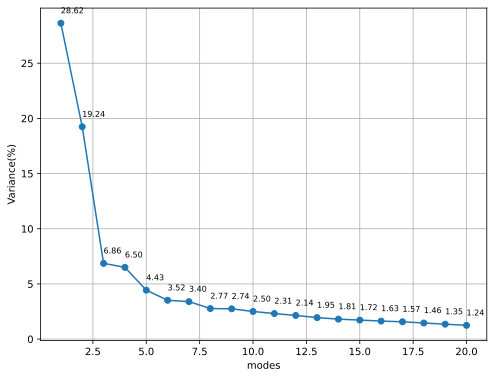

In [73]:
#prm_mod
prm_file_list = []
for y in range(1994,2017):
    filename = "../data/ncc_csm\\MODES_NCC_CSM11_" + str(y) + "0315_" + str(y) + "03_13_ENS.nc"
    prm_file_list.append(filename)
prm_arrays = []
for f in prm_file_list:
    nc = netCDF4.Dataset(f)
    dt = nc.variables['precsfc'][3:6,:,:]#3月起报678月数据
    dt[0,:,:] = dt[0,:,:] * 30
    dt[1:2,:,:] = dt[1:2,:,:] * 31
    dty = np.sum(dt, axis=0)
    prm_arrays.append(dty)
prm = np.stack(prm_arrays, axis=0)
# prm = prm.filled(fill_value=0)

lon = np.linspace(0, 360, 144)
lat = np.linspace(90, -90, 73)
time = xr.cftime_range(start='1994', end='2016', freq='YS')
ds = xr.Dataset({'prm': ([ 'time', 'lat', 'lon'], prm)}, coords={'lon': lon, 'lat': lat, 'time': time})
sub_ds = ds.sel(lon=slice(70, 140), lat=slice(60, 0))
time_mean = sub_ds.mean(dim="time")
ano = (sub_ds-time_mean)/time_mean
# ano = sub_ds-time_mean
ano = ano.transpose('time', 'lat', 'lon')

coslat = np.cos(np.deg2rad(ano.coords['lat'].values)) 
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(ano['prm'], weights=wgts, center=False)# 创建EOF求解器对象
eof_s = solver.eofs(neofs=20, eofscaling=0)# 计算EOF模态 shape:(1, 25, 28)
pcs = solver.pcs(npcs=20, pcscaling=0)# 计算主成分 shape:(23, 1)时间，主成分
delta = solver.northTest()
eigenvalues = solver.eigenvalues()
print('eigenvalues:', eigenvalues, 'eigenvalues')
print('north_test:', delta, 'north_test')
significant_modes = []
for k in range(len(eigenvalues) - 1):
    if eigenvalues[k] - eigenvalues[k+1] > delta[k] + delta[k+1]:
        significant_modes.append(k + 1)  # 模态编号从 1 开始

print("Significant modes by North test:", significant_modes)
# np.save('./data2/prmmodeof.npy', eof_s)
# np.save('./data2/prmmodpcs.npy', pcs)
variance = solver.varianceFraction(neigs=20)
prm_mod_list = []
var_max = 0
for i in range(np.shape(eof_s)[0]):
    var_max = var_max + variance[i].values
    a = np.multiply(pcs[:,i], eof_s[i])
    prm_mod_list.append(a)
    if var_max >= 1:
        break    
prm_mod = np.sum(prm_mod_list, axis=0)
prm_mod = xr.DataArray(prm_mod,coords=ano['prm'].coords)
print(prm_mod)
plt.figure(figsize=(8, 6),dpi=100)
plt.plot(np.arange(1, 21), variance[:20]*100, 'o-')
plt.xlabel('modes')
plt.ylabel('Variance(%)')
plt.grid()
for i, v in enumerate(variance.values[:20]*100):
    plt.text(i+1, v+0.9, f'{v:.2f}', fontsize=8, color='black')
plt.show(block=True)
# ds_ano = xr.DataArray(ano, dims=['time', 'lat', 'lon'])
# np.save('./mod.npy', ano['prm'])

In [74]:
#slp_mod
slp_file_list = []
for y in range(1994,2017):#1994到2016
    filename = "../data/ncc_csm\\\\MODES_NCC_CSM11_"+str(y)+"0315_"+str(y)+"03_13_ENS.nc" #bcc模式数据
    slp_file_list.append(filename)
slp_arrays = []
for f in slp_file_list:
    nc = netCDF4.Dataset(f)
    dt = nc.variables['slp'][3:6,:,:] # 3月起报的678月数据[3:6,:,:]
    dty = np.sum(dt, axis=0)
    slp_arrays.append(dty)
slp = np.stack(slp_arrays, axis=0)
slp = slp.filled(fill_value=0)


lon = np.linspace(0, 360, 144)
lat = np.linspace(90, -90, 73)
time = xr.cftime_range(start='1994', end='2016', freq='YS')
ds = xr.Dataset({'slp': ([ 'time', 'lat', 'lon'], slp)}, coords={'lon': lon, 'lat': lat, 'time': time})

sub_ds = ds.sel(lon=slice(60, 180), lat=slice(60, 0))
time_mean = sub_ds.mean(dim="time")
space_mean = sub_ds.mean(dim=['lat', 'lon'])
ano = (sub_ds-time_mean)/time_mean
ano = ano.transpose('time', 'lat', 'lon')
coslat = np.cos(np.deg2rad(ano.coords['lat'].values)) 
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(ano['slp'], weights=wgts, center=False)# 创建EOF求解器对象
eof_s = solver.eofs(neofs=20, eofscaling=0)# 计算EOF模态 shape:(1, 25, 28)
pcs = solver.pcs(npcs=20, pcscaling=0)# 计算主成分 shape:(23, 1)时间，主成分
delta = solver.northTest()
eigenvalues = solver.eigenvalues()
print('eigenvalues:', eigenvalues, 'eigenvalues')
print('north_test:', delta, 'north_test')
significant_modes = []
for k in range(len(eigenvalues) - 1):
    if eigenvalues[k] - eigenvalues[k+1] > delta[k] + delta[k+1]:
        significant_modes.append(k + 1)  # 模态编号从 1 开始

print("Significant modes by North test:", significant_modes)
# np.save('./data2/slpmodeof.npy', eof_s)
# np.save('./data2/slpmodpcs.npy', pcs)
variance = solver.varianceFraction(neigs=10)
slp_mod_list = []
var_max = 0
for i in range(np.shape(eof_s)[0]):
    var_max = var_max + variance[i].values
    a = np.multiply(pcs[:,i], eof_s[i])
    slp_mod_list.append(a)
    if var_max >= 1:
        break    
slp_mod = np.sum(slp_mod_list, axis=0)
slp_mod = xr.DataArray(slp_mod,coords=ano['slp'].coords)
print(slp_mod)
plt.figure(figsize=(8, 6),dpi=100)
plt.plot(np.arange(1, 11), variance[:10]*100, 'o-')
plt.xlabel('modes', fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel('Variance(%)', fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
for i, v in enumerate(variance.values[:10]*100):
    plt.text(i+1, v+0.9, f'{v:.2f}', fontsize=14, color='black')
plt.show(block=True)

eigenvalues: <xarray.DataArray 'eigenvalues' (mode: 23)> Size: 92B
array([1.32145447e-04, 5.01389623e-05, 1.15761795e-05, 7.96140739e-06,
       6.95321978e-06, 3.18630327e-06, 2.78475909e-06, 1.93980713e-06,
       1.46152297e-06, 1.22646770e-06, 9.95564847e-07, 7.41234487e-07,
       7.12390147e-07, 6.46392493e-07, 4.21142602e-07, 3.86388564e-07,
       3.34168931e-07, 2.30659538e-07, 2.06031913e-07, 1.89755099e-07,
       1.55805481e-07, 1.15749714e-07, 6.50677298e-12], dtype=float32)
Coordinates:
  * mode     (mode) int64 184B 0 1 2 3 4 5 6 7 8 ... 14 15 16 17 18 19 20 21 22
Attributes:
    long_name:  eigenvalues eigenvalues
north_test: <xarray.DataArray 'typical_errors' (mode: 23)> Size: 184B
array([3.89675665e-05, 1.47851733e-05, 3.41362911e-06, 2.34769096e-06,
       2.05039265e-06, 9.39589575e-07, 8.21180655e-07, 5.72017917e-07,
       4.30979611e-07, 3.61665594e-07, 2.93576057e-07, 2.18578126e-07,
       2.10072394e-07, 1.90610747e-07, 1.24188178e-07, 1.13939771e-07,
       9

IndexError: index 10 is out of bounds for axis 0 with size 10

eigenvalues: <xarray.DataArray 'eigenvalues' (mode: 23)> Size: 92B
array([2.30152000e+05, 9.47260703e+04, 3.40889141e+04, 2.65876699e+04,
       1.05285762e+04, 7.19674268e+03, 5.14513867e+03, 3.40036792e+03,
       3.17034399e+03, 2.57955762e+03, 2.17366040e+03, 1.53704773e+03,
       1.44664014e+03, 1.17421448e+03, 9.01100159e+02, 7.60784912e+02,
       6.10202454e+02, 4.30678619e+02, 3.52525208e+02, 2.51500687e+02,
       2.14126846e+02, 1.08389404e+02, 3.26414569e-03], dtype=float32)
Coordinates:
  * mode     (mode) int64 184B 0 1 2 3 4 5 6 7 8 ... 14 15 16 17 18 19 20 21 22
Attributes:
    long_name:  eigenvalues eigenvalues
north_test: <xarray.DataArray 'typical_errors' (mode: 23)> Size: 184B
array([6.78681222e+04, 2.79331942e+04, 1.00522723e+04, 7.84027613e+03,
       3.10470773e+03, 2.12220364e+03, 1.51721862e+03, 1.00271380e+03,
       9.34883440e+02, 7.60670042e+02, 6.40977483e+02, 4.53250648e+02,
       4.26590903e+02, 3.46256959e+02, 2.65719940e+02, 2.24343231e+02,
       1

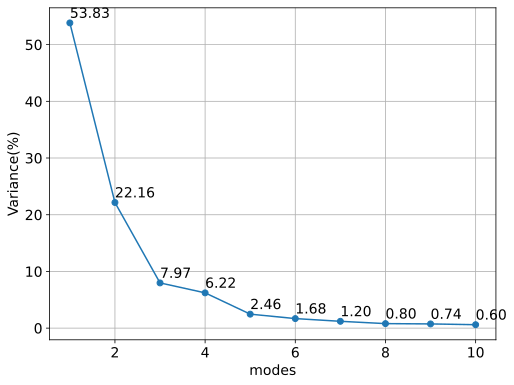

In [ ]:
#gh5_mod
gh5_file_list = []
for y in range(1994,2017):#1994到2016
    filename = "../data/ncc_csm\\\\MODES_NCC_CSM11_"+str(y)+"0215_"+str(y)+"02_13_ENS.nc" #bcc模式数据2月
    gh5_file_list.append(filename)
gh5_arrays = []
for f in gh5_file_list:
    nc = netCDF4.Dataset(f)#文中用的2月起报678月
    dt = nc.variables['h500'][4:7,:,:] # 2月起报的
    dty = np.sum(dt, axis=0)
    gh5_arrays.append(dty)
gh5 = np.stack(gh5_arrays, axis=0)

lon = np.linspace(0, 360, 144)
lat = np.linspace(90, -90, 73)
time = xr.cftime_range(start='1994', end='2016', freq='YS')
ds = xr.Dataset({'gh5': ([ 'time', 'lat', 'lon'], gh5)}, coords={'lon': lon, 'lat': lat, 'time': time})

sub_ds = ds.sel(lon=slice(70, 180), lat=slice(60, -30))
time_mean = sub_ds.mean(dim="time")
space_mean = sub_ds.mean(dim=['lat', 'lon'])
ano = sub_ds-time_mean
ano = ano.transpose('time', 'lat', 'lon')
coslat = np.cos(np.deg2rad(ano.coords['lat'].values)) 
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(ano['gh5'], weights=wgts, center=False)# 创建EOF求解器对象
eof_s = solver.eofs(neofs=20, eofscaling=0)# 计算EOF模态 shape:(1, 25, 28)
pcs = solver.pcs(npcs=20, pcscaling=0)# 计算主成分 shape:(23, 1)时间，主成分
delta = solver.northTest()
eigenvalues = solver.eigenvalues()
print('eigenvalues:', eigenvalues, 'eigenvalues')
print('north_test:', delta, 'north_test')
significant_modes = []
for k in range(len(eigenvalues) - 1):
    if eigenvalues[k] - eigenvalues[k+1] > delta[k] + delta[k+1]:
        significant_modes.append(k + 1)  # 模态编号从 1 开始

print("Significant modes by North test:", significant_modes)

# np.save('./data2/gh5modeof.npy', eof_s)
# np.save('./data2/gh5modpcs.npy', pcs)
variance = solver.varianceFraction(neigs=10)
gh5_mod_list = []
var_max = 0
for i in range(np.shape(eof_s)[0]):
    var_max = var_max + variance[i].values
    a = np.multiply(pcs[:,i], eof_s[i])
    gh5_mod_list.append(a)
    if var_max >= 1:
        break    
gh5_mod = np.sum(gh5_mod_list, axis=0)
gh5_mod = xr.DataArray(gh5_mod,coords=ano['gh5'].coords)
print(gh5_mod)
plt.figure(figsize=(8, 6),dpi=100)
plt.plot(np.arange(1, 11), variance[:10]*100, 'o-')
plt.xlabel('modes', fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel('Variance(%)', fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
for i, v in enumerate(variance.values[:10]*100):
    plt.text(i+1, v+0.9, f'{v:.2f}', fontsize=14, color='black')
plt.show(block=True)

观测数据

In [ ]:
# #将观测值从acc里的observe插值为格点数据
# data_arrays = []

# # 循环读取observe_年份.csv文件
# for filename in os.listdir('./求acc模式/observe/'):  # 根据实际路径设置
#     if filename.startswith("observe_") and filename.endswith(".csv"):
#         year = filename.split("_")[1].split(".")[0]
#         obser_df = pd.read_csv('./求acc模式/observe/'+filename)


#         # 将数据整合到 xarray.DataArray 中
#         target_lons = np.arange(70, 140, 1)
#         target_lats = np.arange(60, 0, -1)
#         # 创建目标经纬度的网格
#         target_grid_lon, target_grid_lat = np.meshgrid(target_lons, target_lats)

#         # 插值
#         grid_z = griddata((obser_df['Long']/100, obser_df['Lat']/100),obser_df['obs_percent'], (target_grid_lon, target_grid_lat),method='linear')
#         # print(grid_z)
#         # 创建插值后的xarray.DataArray
#         gridd_site_data = xr.DataArray(grid_z, coords=[('lat', target_lats), ('lon', target_lons)])



#         # 存储每次循环生成的二维数组
#         data_arrays.append(gridd_site_data)

# # 将二维数组整合为三维数组
# final_array = xr.concat(data_arrays, dim='Year')
# print(final_array)
# np.save('./obs.npy', final_array)


eigenvalues: <xarray.DataArray 'eigenvalues' (mode: 23)> Size: 184B
array([4.06502543e+01, 3.07856057e+01, 2.80868046e+01, 2.05796551e+01,
       1.71197752e+01, 1.48491511e+01, 1.30139388e+01, 1.12788984e+01,
       1.04472736e+01, 1.02926211e+01, 9.91095212e+00, 9.50978063e+00,
       8.11903712e+00, 7.67313028e+00, 7.21261156e+00, 6.75777210e+00,
       6.69770409e+00, 6.44938256e+00, 6.07893634e+00, 5.91140290e+00,
       5.54860206e+00, 5.29171552e+00, 7.43930468e-30])
Coordinates:
  * mode     (mode) int64 184B 0 1 2 3 4 5 6 7 8 ... 14 15 16 17 18 19 20 21 22
Attributes:
    long_name:  eigenvalues eigenvalues
north_test: <xarray.DataArray 'typical_errors' (mode: 23)> Size: 184B
array([1.19871060e+01, 9.07817985e+00, 8.28234681e+00, 6.06860921e+00,
       5.04834629e+00, 4.37877577e+00, 3.83760120e+00, 3.32596568e+00,
       3.08073292e+00, 3.03512839e+00, 2.92258034e+00, 2.80428132e+00,
       2.39417343e+00, 2.26268268e+00, 2.12688312e+00, 1.99275827e+00,
       1.97504518e+00,

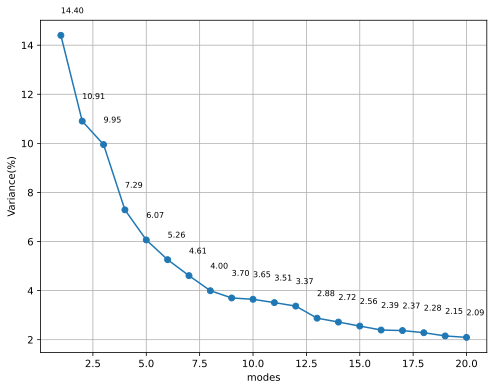

In [ ]:
#prm_obs
df = pd.read_csv('./result.csv')
df = df.groupby(['Stn_No','time'])['Precip'].mean().reset_index()
# 转换为xarray数据表
df = df.set_index(['Stn_No', 'time'])
xr_data = xr.Dataset.from_dataframe(df)

# print(xr_data)
xr_data = xr_data.dropna(dim='Stn_No')
means = xr_data.groupby('Stn_No').mean(dim='time')
ano = (xr_data-means)/means
prm_obs = ano['Precip']
prm_obs['time'] = xr.cftime_range(start='1994', end='2016', freq='YS')
prm_obs = prm_obs.transpose('time', 'Stn_No')
solver = Eof(prm_obs, center=False)# 创建EOF求解器对象
eof_s = solver.eofs(neofs=20, eofscaling=0)# 计算EOF模态 shape:(1, 25, 28)
pcs = solver.pcs(npcs=20, pcscaling=0)# 计算主成分 shape:(23, 1)时间，主成分
delta = solver.northTest()
eigenvalues = solver.eigenvalues()
print('eigenvalues:', eigenvalues, 'eigenvalues')
print('north_test:', delta, 'north_test')
significant_modes = []
for k in range(len(eigenvalues) - 1):
    if eigenvalues[k] - eigenvalues[k+1] > delta[k] + delta[k+1]:
        significant_modes.append(k + 1)  # 模态编号从 1 开始

print("Significant modes by North test:", significant_modes)
# np.save('./data2/prmobseof.npy', eof_s)
# np.save('./data2/prmobspcs.npy', pcs)
variance = solver.varianceFraction(neigs=20)
prm_obs_list = []
var_max = 0
for i in range(np.shape(eof_s)[0]):
    var_max = var_max + variance[i].values
    a = np.multiply(pcs[:,i], eof_s[i])
    prm_obs_list.append(a)
    if var_max >= 1:
        break
prm_obs = np.sum(prm_obs_list, axis=0)
prm_obs = xr.DataArray(prm_obs.T,coords=ano['Precip'].coords).T
prm_obs['time'] = xr.cftime_range(start='1994', end='2016', freq='YS')
print(prm_obs)
plt.figure(figsize=(8, 6),dpi=100)
plt.plot(np.arange(1, 21), variance[:20]*100, 'o-')
plt.xlabel('modes')
plt.ylabel('Variance(%)')
plt.grid()
for i, v in enumerate(variance.values[:20]*100):
    plt.text(i+1, v+0.9, f'{v:.2f}', fontsize=8, color='black')
plt.show(block=True)
# prm_obs.to_netcdf('./123456789.nc')

In [ ]:
# #sst_obs()
# ssta_list = []
# for y in range(1993,2016): #1993到2015年的
#     sst_file_list = []
#     for m in [9,10,11,12,13,14]: # 从1到12代表每个月
#         if m > 12:
#             mm = m-12
#             yy = y+1
#         else:
#             mm = m
#             yy = y
#         month_str = str(mm).zfill(2) # 把数字转化为两位数的字符串，例如: 1 => '01'
#         filename = "../data/ncep_cfs2\\\\MODESv21_ncep_cfs2_" + str(yy) + month_str + "_monthly_em.nc" #ncep观测数据
#         sst_file_list.append(filename)
#     sst_arrays = []
#     for f in sst_file_list:
#         nc = netCDF4.Dataset(f)
#         dt = nc.variables['sst'][0:1,:,:] # 取每个文件中的第一份数据
#         dty = np.sum(dt, axis=0)
#         sst_arrays.append(dty)
#     sst = np.stack(sst_arrays, axis=0)
#     ssta = np.sum(sst,axis=0)
#     ssta_list.append(ssta)

# sste = np.stack(ssta_list, axis=0)
# sste = sste.filled(fill_value=0)


# lon = np.linspace(0, 360, 360)
# lat = np.linspace(90, -90, 180)
# time = xr.cftime_range(start='1994', end='2016', freq='YS')
# ds = xr.Dataset({'sst': ([ 'time', 'lat', 'lon'], sste)}, coords={'lon': lon, 'lat': lat, 'time': time})

# sub_ds = ds.sel(lon=slice(160, 210), lat=slice(10, -10))
# time_mean = sub_ds.mean(dim="time")
# space_mean = sub_ds.mean(dim=['lat', 'lon'])
# ano = (sub_ds-time_mean)/time_mean
# ano = ano.transpose('time', 'lat', 'lon')
# coslat = np.cos(np.deg2rad(ano.coords['lat'].values)) 
# wgts = np.sqrt(coslat)[..., np.newaxis]
# solver = Eof(ano['sst'], weights=wgts, center=False)# 创建EOF求解器对象
# eof_s = solver.eofs(neofs=10, eofscaling=0)# 计算EOF模态 shape:(1, 25, 28)
# pcs = solver.pcs(npcs=10, pcscaling=0)# 计算主成分 shape:(23, 1)时间，主成分
# variance = solver.varianceFraction(neigs=10)
# sst_mod_list = []
# var_max = 0
# for i in range(np.shape(eof_s)[0]):
#     var_max = var_max + variance[i].values
#     if var_max >= 0.7:
#         break
#     a = np.multiply(pcs[:,i], eof_s[i])
#     sst_mod_list.append(a)
# sst_mod = np.sum(sst_mod_list, axis=0)
# # print(prm_mod)
# plt.figure(figsize=(8, 6),dpi=100)
# plt.plot(np.arange(1, 11), variance[:10]*100, 'o-')
# plt.xlabel('modes')
# plt.ylabel('Variance(%)')
# plt.grid()
# for i, v in enumerate(variance.values[:10]*100):
#     plt.text(i+1, v+0.9, f'{v:.2f}', fontsize=8, color='black')
# plt.show()

eigenvalues: <xarray.DataArray 'eigenvalues' (mode: 23)> Size: 92B
array([5.4162890e-01, 5.9987549e-02, 8.8359825e-03, 7.8656664e-03,
       3.9649885e-03, 3.0253201e-03, 1.7767348e-03, 1.3583240e-03,
       1.1544217e-03, 6.0932629e-04, 5.5876881e-04, 4.7425396e-04,
       4.3576432e-04, 4.0810031e-04, 2.9965083e-04, 2.7038075e-04,
       2.4460314e-04, 2.3873766e-04, 2.1931709e-04, 1.8690225e-04,
       1.6281624e-04, 1.3698651e-04, 5.3347678e-12], dtype=float32)
Coordinates:
  * mode     (mode) int64 184B 0 1 2 3 4 5 6 7 8 ... 14 15 16 17 18 19 20 21 22
Attributes:
    long_name:  eigenvalues eigenvalues
north_test: <xarray.DataArray 'typical_errors' (mode: 23)> Size: 184B
array([1.59717648e-01, 1.76893631e-02, 2.60558910e-03, 2.31945848e-03,
       1.16921133e-03, 8.92118235e-04, 5.23930519e-04, 4.00547884e-04,
       3.40420391e-04, 1.79680521e-04, 1.64771932e-04, 1.39849863e-04,
       1.28499887e-04, 1.20342217e-04, 8.83622080e-05, 7.97309348e-05,
       7.21295318e-05, 7.039989

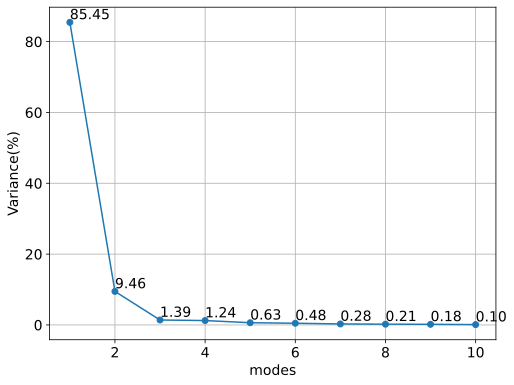

In [ ]:
#sst_ncep
sst_ncep_file = "E:/D1/f01/data/sst.oisst.mon.mean.1982.nc"
nc = netCDF4.Dataset(sst_ncep_file)
sst_list = []
for i in range(1993,2016):
    st = (i-1993)*12-3+144-1
    en = (i-1993)*12+2+144
    dt = nc.variables['sst'][st:en,:,:]
    dty = np.sum(dt,axis=0)
    sst_list.append(dty)

sste = np.stack(sst_list, axis=0)

lon = np.linspace(0, 360, 360)
lat = np.linspace(90, -90, 180)
time = xr.cftime_range(start='1994', end='2016', freq='YS')
ds = xr.Dataset({'t': ([ 'time', 'lat', 'lon'], sste)}, coords={'lon': lon, 'lat': lat, 'time': time})

sub_ds = ds.sel(lon=slice(160, 210), lat=slice(10, -10))
time_mean = sub_ds.mean(dim="time")
space_mean = sub_ds.mean(dim=['lat', 'lon'])
ano = (sub_ds-time_mean)/time_mean
ano = ano.transpose('time', 'lat', 'lon')
coslat = np.cos(np.deg2rad(ano.coords['lat'].values)) 
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(ano['t'], weights=wgts, center=False)# 创建EOF求解器对象
eof_s = solver.eofs(neofs=20, eofscaling=0)# 计算EOF模态 shape:(1, 25, 28)
pcs = solver.pcs(npcs=20, pcscaling=0)# 计算主成分 shape:(23, 1)时间，主成分
delta = solver.northTest()
eigenvalues = solver.eigenvalues()
print('eigenvalues:', eigenvalues, 'eigenvalues')
print('north_test:', delta, 'north_test')
significant_modes = []
for k in range(len(eigenvalues) - 1):
    if eigenvalues[k] - eigenvalues[k+1] > delta[k] + delta[k+1]:
        significant_modes.append(k + 1)  # 模态编号从 1 开始

print("Significant modes by North test:", significant_modes)
# np.save('./data2/sstobseof.npy', eof_s)
# np.save('./data2/sstobspcs.npy', pcs)
variance = solver.varianceFraction(neigs=10)
sst_obs_list = []
var_max = 0
for i in range(np.shape(eof_s)[0]):
    var_max = var_max + variance[i].values
    a = np.multiply(pcs[:,i], eof_s[i])
    sst_obs_list.append(a)
    if var_max >= 1:
        break    
sst_obs = np.sum(sst_obs_list, axis=0)
sst_obs = xr.DataArray(sst_obs,coords=ano['t'].coords)
print(sst_obs)
plt.figure(figsize=(8, 6),dpi=100)
plt.plot(np.arange(1, 11), variance[:10]*100, 'o-')
plt.xlabel('modes', fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel('Variance(%)', fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
for i, v in enumerate(variance.values[:10]*100):
    plt.text(i+1, v+0.9, f'{v:.2f}', fontsize=14, color='black')
plt.show(block=True)

[[[303798.47 303798.38 303798.28 ... 303798.88 303798.75 303798.6 ]
  [303837.2  303836.78 303836.34 ... 303838.47 303838.06 303837.6 ]
  [303875.56 303875.03 303874.44 ... 303877.4  303876.8  303876.16]
  ...
  [306565.53 306605.47 306644.84 ... 306443.16 306484.38 306525.2 ]
  [306917.75 306938.34 306958.75 ... 306855.3  306876.25 306897.06]
  [307058.75 307064.97 307071.2  ... 307039.94 307046.22 307052.47]]

 [[304124.38 304124.1  304123.78 ... 304125.25 304124.97 304124.7 ]
  [304142.56 304141.62 304140.62 ... 304145.62 304144.66 304143.6 ]
  [304166.25 304164.5  304162.75 ... 304171.62 304169.88 304167.97]
  ...
  [307097.38 307134.7  307171.38 ... 306983.1  307021.56 307059.66]
  [307487.28 307506.5  307525.62 ... 307429.03 307448.53 307467.94]
  [307657.53 307663.3  307669.1  ... 307639.88 307645.78 307651.7 ]]

 [[303962.   303962.   303962.03 ... 303961.84 303961.94 303961.94]
  [304007.56 304007.66 304007.7  ... 304007.4  304007.4  304007.47]
  [304052.2  304052.44 304052.72

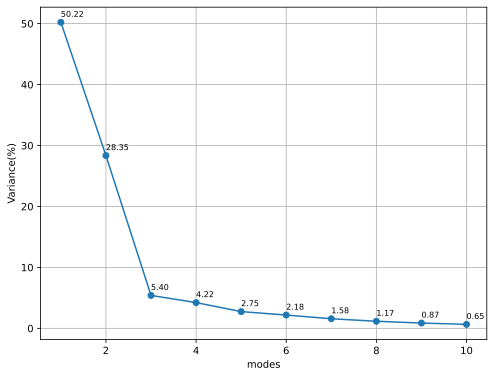

In [ ]:
#slp_obs
ssta_list = []
for y in range(1994,2017): #1994到2016年的
    sst_file_list = []
    for m in [6,7,8]: # 从1到12代表每个月
        month_str = str(m).zfill(2) # 把数字转化为两位数的字符串，例如: 1 => '01'
        filename = "../data/ncep_cfs21\\\\MODESv21_ncep_cfs2_" + str(y) + month_str + "_monthly_em.nc" #ncep观测数据
        sst_file_list.append(filename)
    sst_arrays = []
    for f in sst_file_list:
        nc = netCDF4.Dataset(f)
        dt = nc.variables['slp'][0:1,:,:] # 取每个文件中的第一份数据
        dty = np.sum(dt, axis=0)
        sst_arrays.append(dty)
    sst = np.stack(sst_arrays, axis=0)
    ssta = np.sum(sst,axis=0)
    ssta_list.append(ssta)

sste = np.stack(ssta_list, axis=0)
print(sste)
sste = sste.filled(fill_value=0)


lon = np.linspace(0, 360, 360)
lat = np.linspace(90, -90, 180)
time = xr.cftime_range(start='1994', end='2016', freq='YS')
ds = xr.Dataset({'t': ([ 'time', 'lat', 'lon'], sste)}, coords={'lon': lon, 'lat': lat, 'time': time})

sub_ds = ds.sel(lon=slice(60, 180), lat=slice(60, 0))
time_mean = sub_ds.mean(dim="time")
ano = (sub_ds-time_mean)/time_mean
ano = ano.transpose('time', 'lat', 'lon')
coslat = np.cos(np.deg2rad(ano.coords['lat'].values)) 
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(ano['t'], weights=wgts, center=False)# 创建EOF求解器对象
eof_s = solver.eofs(neofs=10, eofscaling=0)# 计算EOF模态 shape:(1, 25, 28)
pcs = solver.pcs(npcs=10, pcscaling=0)# 计算主成分 shape:(23, 1)时间，主成分
delta = solver.northTest()
eigenvalues = solver.eigenvalues()
print('eigenvalues:', eigenvalues, 'eigenvalues')
print('north_test:', delta, 'north_test')
significant_modes = []
for k in range(len(eigenvalues) - 1):
    if eigenvalues[k] - eigenvalues[k+1] > delta[k] + delta[k+1]:
        significant_modes.append(k + 1)  # 模态编号从 1 开始

print("Significant modes by North test:", significant_modes)
variance = solver.varianceFraction(neigs=10)
slp_obs_list = []
var_max = 0
for i in range(np.shape(eof_s)[0]):
    var_max = var_max + variance[i].values
    a = np.multiply(pcs[:,i], eof_s[i])
    slp_obs_list.append(a)
    if var_max >= 1:
        break    
slp_obs = np.sum(slp_obs_list, axis=0)
slp_obs = xr.DataArray(slp_obs,coords=ano['t'].coords)
print(slp_obs)
plt.figure(figsize=(8, 6),dpi=100)
plt.plot(np.arange(1, 11), variance[:10]*100, 'o-')
plt.xlabel('modes')
plt.ylabel('Variance(%)')
plt.grid()
for i, v in enumerate(variance.values[:10]*100):
    plt.text(i+1, v+0.9, f'{v:.2f}', fontsize=8, color='black')
plt.show(block=True)

eigenvalues: <xarray.DataArray 'eigenvalues' (mode: 23)> Size: 92B
array([8.7420754e-03, 3.8716786e-03, 2.3893609e-03, 1.0649509e-03,
       9.5565600e-04, 5.4691482e-04, 4.5736719e-04, 3.4792835e-04,
       2.9019907e-04, 2.1552118e-04, 1.9838038e-04, 1.4491905e-04,
       1.1787151e-04, 7.7411103e-05, 5.1851643e-05, 4.2090014e-05,
       3.9739927e-05, 3.7278976e-05, 2.4400242e-05, 1.9222229e-05,
       1.8223558e-05, 1.0970679e-05, 5.6268715e-11], dtype=float32)
Coordinates:
  * mode     (mode) int64 184B 0 1 2 3 4 5 6 7 8 ... 14 15 16 17 18 19 20 21 22
Attributes:
    long_name:  eigenvalues eigenvalues
north_test: <xarray.DataArray 'typical_errors' (mode: 23)> Size: 184B
array([2.57789740e-03, 1.14169573e-03, 7.04584095e-04, 3.14036902e-04,
       2.81807579e-04, 1.61276381e-04, 1.34870226e-04, 1.02598472e-04,
       8.55750361e-05, 6.35537300e-05, 5.84991830e-05, 4.27342952e-05,
       3.47584121e-05, 2.28272889e-05, 1.52902152e-05, 1.24116680e-05,
       1.17186652e-05, 1.099297

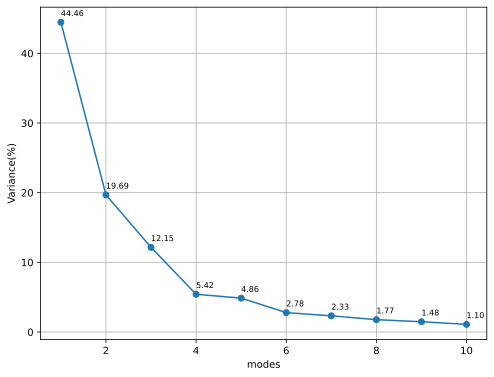

In [ ]:
#gh5_obs
ssta_list = []
for y in range(1994,2017): #1994到2016年的
    sst_file_list = []
    for m in [6]: # 从1到12代表每个月
        month_str = str(m).zfill(2) # 把数字转化为两位数的字符串，例如: 1 => '01'
        filename = "../data/ncep_cfs21\\\\MODESv21_ncep_cfs2_" + str(y) + month_str + "_monthly_em.nc" #ncep观测数据
        sst_file_list.append(filename)
    sst_arrays = []
    for f in sst_file_list:
        nc = netCDF4.Dataset(f)
        dt = nc.variables['h500'][0:1,:,:] # 取每个文件中的第一份数据
        dty = np.sum(dt, axis=0)
        sst_arrays.append(dty)
    sst = np.stack(sst_arrays, axis=0)
    ssta = np.sum(sst,axis=0)
    ssta_list.append(ssta)

gh5e = np.stack(ssta_list, axis=0)
gh5e = gh5e.filled(fill_value=0)


lon = np.linspace(0, 360, 360)
lat = np.linspace(90, -90, 180)
time = xr.cftime_range(start='1994', end='2016', freq='YS')
ds = xr.Dataset({'t': ([ 'time', 'lat', 'lon'], gh5e)}, coords={'lon': lon, 'lat': lat, 'time': time})

sub_ds = ds.sel(lon=slice(70, 180), lat=slice(60, -30))
time_mean = sub_ds.mean(dim="time")
ano = (sub_ds-time_mean)/time_mean

ano = ano.transpose('time', 'lat', 'lon')
coslat = np.cos(np.deg2rad(ano.coords['lat'].values)) 
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(ano['t'], weights=wgts, center=False)# 创建EOF求解器对象
eof_s = solver.eofs(neofs=10, eofscaling=0)# 计算EOF模态 shape:(1, 25, 28)
pcs = solver.pcs(npcs=10, pcscaling=0)# 计算主成分 shape:(23, 1)时间，主成分
delta = solver.northTest()
eigenvalues = solver.eigenvalues()
print('eigenvalues:', eigenvalues, 'eigenvalues')
print('north_test:', delta, 'north_test')
significant_modes = []
for k in range(len(eigenvalues) - 1):
    if eigenvalues[k] - eigenvalues[k+1] > delta[k] + delta[k+1]:
        significant_modes.append(k + 1)  # 模态编号从 1 开始

print("Significant modes by North test:", significant_modes)
variance = solver.varianceFraction(neigs=10)
gh5_obs_list = []
var_max = 0
for i in range(np.shape(eof_s)[0]):
    var_max = var_max + variance[i].values
    a = np.multiply(pcs[:,i], eof_s[i])
    gh5_obs_list.append(a)
    if var_max >= 1:
        break
gh5_obs = np.sum(gh5_obs_list, axis=0)
gh5_obs = xr.DataArray(gh5_obs,coords=ano['t'].coords)
print(gh5_obs)
plt.figure(figsize=(8, 6),dpi=100)
plt.plot(np.arange(1, 11), variance[:10]*100, 'o-')
plt.xlabel('modes')
plt.ylabel('Variance(%)')
plt.grid()
for i, v in enumerate(variance.values[:10]*100):
    plt.text(i+1, v+0.9, f'{v:.2f}', fontsize=8, color='black')
plt.show(block=True)

使用svd方法进行数据分解

In [ ]:
import itertools
from scipy.stats import pearsonr

# 假设变量已经加载并存储在字典中
variables = {
    'prm_obs': prm_obs,
    'prm_mod': prm_mod,
    'slp_obs': slp_obs,
    'slp_mod': slp_mod,
    'gh5_obs': gh5_obs,
    'gh5_mod': gh5_mod,
    'sst_obs': sst_obs
}

# 存储相关系数结果
correlations = {
    'prm_mod-slp_mod': 0,
    'prm_mod-gh5_mod': 0,
    'prm_obs-sst_obs': 0,
    'prm_obs-slp_obs': 0,
    'prm_obs-gh5_obs': 0,
}

# 遍历所有变量对（有序排列）
def cal_corr(var1, var2, name1, name2):
    # 执行MCA分析
    svd = xMCA(var1, var2)
    svd.solver()
    
    # 获取时间系数（假设取前20个模态中的第一个模态）
    le, re = svd.expansionCoefs(n=20)
    le_mode1 = le[0]
    re_mode1 = re[0]
    
    # 计算相关系数
    corr, _ = pearsonr(le_mode1, re_mode1)
    return corr
for i in correlations:
    var1_name, var2_name = i.split('-')
    var1 = variables[var1_name]
    var2 = variables[var2_name]
    correlations[i] = cal_corr(var1, var2, var1_name, var2_name)

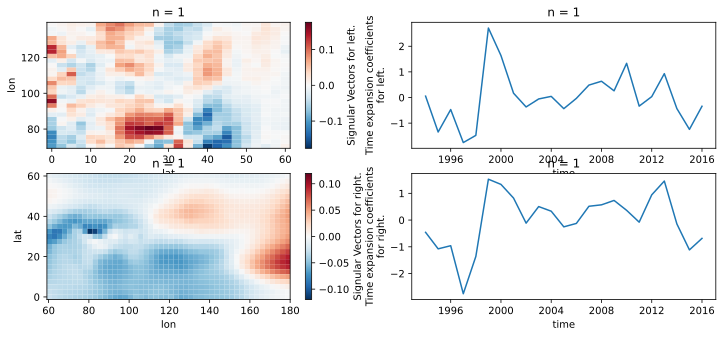

In [32]:
#svd分解，然后求a和b
svd = xMCA(prm_mod, slp_mod) #(23, 25, 28)(23, 25, 48)
svd.solver()
lp, rp = svd.patterns(n=20)
le, re = svd.expansionCoefs(n=20)

show_what = 1
# Convert time coordinates to numpy.datetime64
le['time'] = le['time'].astype('datetime64[ns]')
re['time'] = re['time'].astype('datetime64[ns]')

fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(12, 5))
a = lp[show_what]
b = rp[show_what]
# a = a.transpose('lat', 'lon')
b = b.transpose('lat', 'lon')
a.plot(ax=ax1[0])#(2, 28, 25)lon lat
le[show_what].plot(ax=ax1[1])#(2, 23)
b.plot(ax=ax2[0])#(2, 48, 25)
re[show_what].plot(ax=ax2[1])#(2, 23)
plt.show(block=True)

In [ ]:
#把生成的东西保存
pr_kid = 'obs'

predictor = 'gh5'
pred_kid = 'mod'
np.save('./data2/prm'+pr_kid+'1_'+predictor+pred_kid+'_pcs.npy', le)
np.save('./data2/prm'+pr_kid+'_'+predictor+pred_kid+'1_pcs.npy', re)
np.save('./data2/prm'+pr_kid+'_'+predictor+pred_kid+'1_svd.npy', rp)
np.save('./data2/prm'+pr_kid+'1_'+predictor+pred_kid+'_svd.npy', lp)
# if pr_kid == 'obs':
#     gradd_p = []
#     for i in range(lp.shape[0]):
#         print(i)
#         gradd_p.append(used_func.gred_site_to_net(lp[i]))
#     gradd_np = np.array(gradd_p)
#     np.save('./data2/prmobs1_'+predictor+pred_kid+'_svd.npy', gradd_np)
# elif pr_kid == 'mod':
#     np.save('./data2/prmmod1_'+predictor+pred_kid+'_svd.npy', lp)

1.6804502945403406e-07


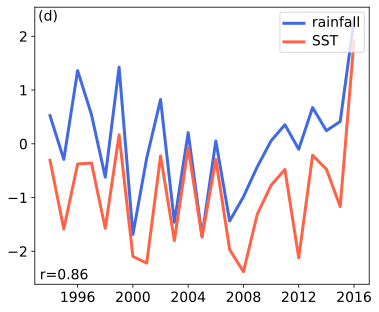

<Figure size 640x480 with 0 Axes>

In [28]:
#时间系数和相关系数及其图像
fig, ax = plt.subplots(figsize=(6, 5))

# Convert the time data to numpy's datetime64 format
time_le = le[0].coords['time'].values.astype('datetime64[ns]')
time_re = re[0].coords['time'].values.astype('datetime64[ns]')

# Now you can use the time data in your plot
ax.plot(time_le, le[show_what].values, label='rainfall', linewidth=3, color='royalblue')  
ax.plot(time_re, re[show_what].values, label='SST', linewidth=3, color='tomato')

plt.setp(ax.get_xticklabels(), fontsize=14)  # 设置X轴刻度标签的字体大小
plt.setp(ax.get_yticklabels(), fontsize=14)  # 设置Y轴刻度标签的字体大小

# co_matrix = np.corrcoef(le[show_what], re[show_what])
corr, p_value = pearsonr(le[show_what], re[show_what])
co = corr
print(p_value)

ax.annotate(f'r={co:.2f}', xy=(0, 0), xycoords='axes fraction', 
            xytext=(5, 5), textcoords='offset points', 
            fontsize=14, color='black')

ax.legend(loc='upper right')
plt.setp(ax.get_legend().get_texts(), fontsize=14)
plt.text(.01, .99, '(d)', ha='left', va='top', transform=ax.transAxes, fontsize=14)
plt.show(block=True)
plt.savefig("./pictures2/gh5/obs.svg",format="svg")

In [8]:
#模态画图——降水——格点数据——地图
import os
import numpy as np
from netCDF4 import Dataset
import xlwt
import pandas as pd
import xarray as xr
from metpy.interpolate import inverse_distance_to_grid
from functools import reduce
import sys
import maskout
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib as mpl
import cartopy.feature as cfeature
from netCDF4 import Dataset
from cartopy.util import add_cyclic_point
import matplotlib.colors as colors
import matplotlib.ticker as ticker

np.set_printoptions(suppress=True)

draw_what = a
draw_what = used_func.gred_site_to_net(a)
class MidpointNormalize(colors.Normalize): 
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))



lon = np.linspace(70, 140, np.shape(draw_what)[1])
lat = np.linspace(60, 0, np.shape(draw_what)[0])
# # 画下面的彩色条子
min_of_draw_what = -0.07
max_of_draw_what = 0.07
# min_of_draw_what = round(float(np.min(draw_what))*0.4, 2)
# max_of_draw_what = round(float(np.max(draw_what))*0.4, 2)
lim = np.concatenate((np.linspace(min_of_draw_what,0,4),np.delete(np.linspace(0,max_of_draw_what,4), 0)),axis=0)
labelsize=14

# 地图界限
with open('../CN-border-La.gmt') as src:
    context = src.read()
    blocks = [cnt for cnt in context.split('>') if len(cnt) > 0]
    borders = [np.fromstring(block, dtype=float, sep=' ') for block in blocks]

fig = plt.figure(figsize=(6,6),facecolor='white')
myproj = ccrs.PlateCarree(central_longitude=0.0)#ccrs跟绘地图有关#调整图像中心位置
ax = fig.add_axes([0.10, 0.15, 0.8, 0.75],projection=myproj)#add_axes通过相对位置增加子图 
ax.add_feature(cfeature.LAND.with_scale('110m'))
for line in borders:
    ax.plot(line[0::2], line[1::2], '-', lw=0.5, color='k',
            transform=ccrs.Geodetic())
    
# Plot gridlines绘制网格线
#ax.gridlines(linestyle='--')

# Set figure extent设置图范围
ax.set_extent([70, 140, 10, 60])#摆正图像
# ax.set_xticks([70,80,90,100,110,120,130,140],crs=ccrs.PlateCarree())
# ax.set_yticks([10,20,30,40,50],crs=ccrs.PlateCarree())
ax.set_xticks(range(70,141,10),crs=ccrs.PlateCarree())
ax.set_yticks(range(10,61,10),crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=False)
lat_formatter = LatitudeFormatter()#定义一种坐标刻度样式为维度刻度	
ax.xaxis.set_major_formatter(lon_formatter)#改变X轴主刻度为经度样式
ax.yaxis.set_major_formatter(lat_formatter)
plt.tick_params(axis='both',labelsize=labelsize)#刻度的字号
cmap1 = mpl.colors.ListedColormap(['#E11300', '#FF3100', '#FF9F00', '#FFBF3B', '#FFE877','#B3F0FA', '#95D2FA', '#77B8FA', '#4FA4F5', '#3B95F5'])
# cmap1.set_over('darkred')
# cmap1.set_under('navy')    #22就是最后一年，2016年
cf=plt.contourf(lon,lat,draw_what,levels=lim,cmap =cmap1,extend='both',zorder=0,transform=ccrs.PlateCarree(),norm=MidpointNormalize(midpoint=0))#画出等高线


colors =mpl.colors.ListedColormap(['black'])
formatter = ticker.FormatStrFormatter('%.2f')
cbar=plt.colorbar(cf,cax=fig.add_axes([0.13, 0.13, 0.75, 0.03]),format=formatter, orientation='horizontal',cmap=cmap1)
cbar.ax.tick_params(labelsize=labelsize)#条子的字号

clip=maskout.shp2clip(cf,ax, r'../data/province/china0.shp')
sub_ax = fig.add_axes([0.76, 0.22, 0.14, 0.155],projection=myproj)#小南海的位置
sub_ax.add_feature(cfeature.LAND.with_scale('110m'))
for line in borders:
    sub_ax.plot(line[0::2], line[1::2], '-', lw=0.4, color='k',
                transform=ccrs.Geodetic())
# Set figure extent设置图范围
sub_ax.set_extent([105, 125, 0, 25]) 
plt.subplots_adjust()
plt.text(.01, .99, '(b)', ha='left', va='top', transform=ax.transAxes, fontsize=16)
plt.show(block=True)
plt.savefig("./pictures/gh5/b.svg",format="svg")

<xarray.DataArray (lat: 60, lon: 70)> Size: 34kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(60, 70))
Coordinates:
  * lat      (lat) int64 480B 60 59 58 57 56 55 54 53 52 ... 9 8 7 6 5 4 3 2 1
  * lon      (lon) int64 560B 70 71 72 73 74 75 76 ... 134 135 136 137 138 139


<Figure size 640x480 with 0 Axes>

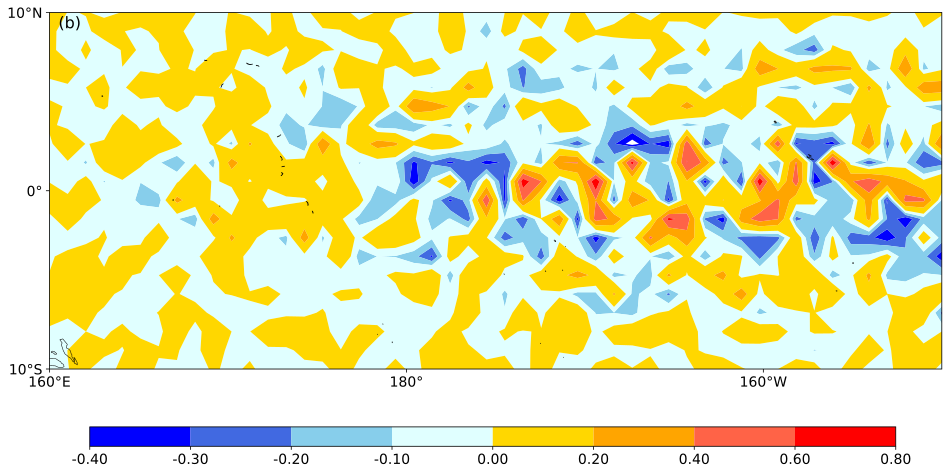

<Figure size 640x480 with 0 Axes>

In [24]:
#模态画图——因子——格点数据
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs       
import cartopy.feature as cfeature 
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter, LatitudeLocator, LongitudeLocator)
import cmaps
import warnings
warnings.filterwarnings('ignore')
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.ticker as ticker


class MidpointNormalize(colors.Normalize): 
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

draw_what = b
picture_type = 'sst'
front_size = 14
min_of_draw_what = -0.4
max_of_draw_what = 0.8
# min_of_draw_what = round(float(np.min(draw_what)-0.1)*1.2, 2)
# max_of_draw_what = round(float(np.max(draw_what)+0.1)*1.2, 2)


if picture_type == 'slp':
    lon_left, lon_right, lat_up, lat_down = 60,180,60,0
    picture_slution = (6,4)
    color_bar_up = 0.12
elif picture_type == 'gh5':
    lon_left, lon_right, lat_up, lat_down = 70,180,60,-30
    picture_slution = (6,6)
    color_bar_up = 0.15
elif picture_type == 'sst':
    lon_left, lon_right, lat_up, lat_down = 160,210,10,-10
    picture_slution = (16,9)
    color_bar_up = 0.16


lon = np.linspace(lon_left, lon_right, np.shape(draw_what)[1])
lat = np.linspace(lat_up, lat_down, np.shape(draw_what)[0])

#检验数据读取
fig = plt.figure(figsize=picture_slution)
projection = ccrs.PlateCarree(central_longitude=180) #指定投影为经纬度投影，中心经纬度为180°
ax1 = fig.add_subplot(1, 1, 1, projection=projection) #绘制第一个子图
# projection = ccrs.PlateCarree(central_longitude=180) #指定投影为经纬度投影，并指定中心经度为180°
# 设置经纬度标签
ax1.set_xticks(range(-180,181,20), crs=projection)
ax1.set_yticks(range(-90,91,10), crs=projection)
plt.tick_params(axis='both',labelsize=front_size)
lon_formatter = LongitudeFormatter(zero_direction_label=True) #给标签添加对应的N,S,E,W
lat_formatter = LatitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.yaxis.set_major_formatter(lat_formatter)
# plt.title('SST anomaly', fontsize=14)

lim = np.concatenate((np.linspace(min_of_draw_what,0,5),np.delete(np.linspace(0,max_of_draw_what,5), 0)),axis=0)
cmap1 = mpl.colors.ListedColormap(['blue','royalblue','skyblue','lightcyan','gold','orange','tomato','red'])
counter = ax1.contourf(lon, lat, draw_what, lim, cmap=cmap1, transform=ccrs.PlateCarree(), norm=MidpointNormalize(midpoint=0))
plt.subplots_adjust(top=1)
ax1.coastlines(color='black', lw=0.5)             #添加海岸线
ax1.add_feature(cfeature.LAND, facecolor='white') #添加陆地
formatter = ticker.FormatStrFormatter('%.2f')
cbar=plt.colorbar(counter,cax=fig.add_axes([0.16, color_bar_up, 0.7, 0.03]),format=formatter,orientation='horizontal',cmap=cmaps.BlueWhiteOrangeRed, norm=MidpointNormalize(midpoint=0))
cbar.ax.tick_params(labelsize=front_size)
ax1.set_extent([lon_left, lon_right, lat_up, lat_down],crs = ccrs.PlateCarree())
plt.text(.01, .99, '(b)', ha='left', va='top', transform=ax1.transAxes, fontsize=16)
plt.show(block=True)
plt.savefig("./pictures2/sst/b.svg",format="svg")


In [ ]:
print(plt.rcParams["font.family"][0])

In [ ]:
#画多张折线图
file_paths = [re]
labels = ['GH5', 'SLP'] 
data_mod1 = le#这里填写pre数据
n_plots = len(file_paths)
n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))
# 创建一个空的figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6))
axes = axes.flatten()
co_array = []
for i, file_path in enumerate(file_paths):
    data_mod2 = file_path
    pcs1 = data_mod1[0]
    pcs2 = data_mod2[0]

    co_matrix = np.corrcoef(pcs1, pcs2)
    co = co_matrix[0,1]
    co_array.append(co)

    # 创建一个子图，并设置位置
    time_pd = xr.cftime_range(start='1994', end='2016', freq='YS').to_datetimeindex()
    ax = axes[i]
    # 绘制折线图
    ax.plot(time_pd, pcs1, color='blue', label='rainfall')#rainfall
    ax.plot(time_pd, pcs2, color='red', label=labels[i])#predictor

    # 设置坐标轴标签和范围
    ax.set_ylabel('Values', color='black')
    ax.tick_params(axis='y', labelcolor='black')
    ax.set_ylim(-1, 1)
    ax.autoscale()
    # 添加图例
    ax.legend()
    # 在图片左下角显示当前r值
    ax.annotate(f'r={co:.2f}', xy=(0, 0), xycoords='axes fraction', 
             xytext=(5, 5), textcoords='offset points', 
             fontsize=12, color='black')
    col_num, row_num = divmod(i, n_cols)
    ax.text(0.01, 0.94, f'({chr(97+row_num+n_cols*col_num)})', transform=ax.transAxes)

# 删除未使用的子图
if n_plots < n_cols * n_rows:
    for ax in axes[n_plots:]:
        ax.remove()

# 调整子图间的间距
plt.tight_layout()

plt.show(block=True)